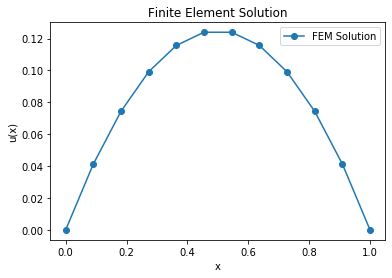

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# Problem setup
L = 1  # Length of the domain
N = 10  # Number of elements
h = L / (N + 1)  # Element size

# Source term
f = np.ones(N)

# Assemble the system matrix
diagonals = [[-2] * N, [1] * (N - 1), [1] * (N - 1)]
A = diags(diagonals, [0, -1, 1]) / h**2

# Solve for u in Au = -f
u = spsolve(A, -f)

# Add boundary values (Dirichlet condition u(0) = u(1) = 0)
u = np.concatenate(([0], u, [0]))

# Plot the solution
x = np.linspace(0, L, N + 2)
plt.plot(x, u, 'o-', label='FEM Solution')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Finite Element Solution')
plt.legend()
plt.show()

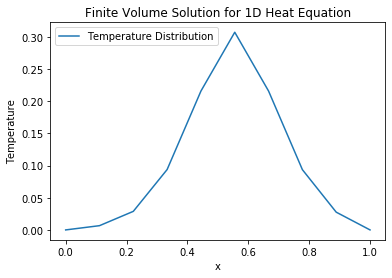

In [3]:
# Parameters
alpha = 0.01  # Diffusion coefficient
dx = 0.1
dt = 0.01
L = 1.0
Nx = int(L / dx)
u = np.zeros(Nx)  # Initial temperature distribution
u[int(Nx/2)] = 1.0  # Initial heat at the center

# FVM discretization loop
for n in range(100):
    u_new = u.copy()
    for i in range(1, Nx - 1):
        u_new[i] = u[i] + alpha * dt / dx**2 * (u[i + 1] - 2 * u[i] + u[i - 1])
    u = u_new

# Plot the final temperature distribution
x = np.linspace(0, L, Nx)
plt.plot(x, u, label='Temperature Distribution')
plt.xlabel('x')
plt.ylabel('Temperature')
plt.title('Finite Volume Solution for 1D Heat Equation')
plt.legend()
plt.show()

In [12]:
from scipy.fft import fft, ifft

# Sample the function on a periodic domain
N = 64
x = np.linspace(0, 2 * np.pi, N, endpoint=False)
f = np.sin(x)

# Compute Fourier transform and reconstruct
f_hat = fft(f)
f_reconstructed = ifft(f_hat).real

# Plot the original and reconstructed function
plt.plot(x, f, label='Original Function')
plt.plot(x, f_reconstructed, '--', label='Reconstructed (Spectral)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Fourier Spectral Approximation of f(x) = sin(x)')
plt.legend()
plt.show()

ModuleNotFoundError: No module named 'scipy.fft'

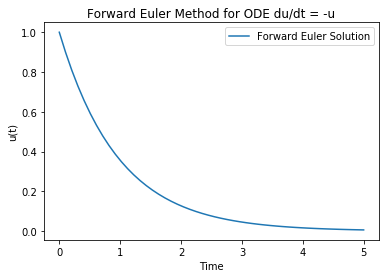

In [8]:
# Define parameters
T = 5.0  # Final time
dt = 0.1  # Time step
N = int(T / dt)
u = np.zeros(N)
u[0] = 1  # Initial condition

# Time-stepping loop
for n in range(1, N):
    u[n] = u[n-1] - dt * u[n-1]

#Plot the solution
t = np.linspace(0, T, N)
plt.plot(t, u, label='Forward Euler Solution')
plt.xlabel('Time')
plt.ylabel('u(t)')
plt.title('Forward Euler Method for ODE du/dt = -u')
plt.legend()
plt.show()

In [9]:
!pip install --upgrade scipy

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 34.5 MB 11.8 MB/s eta 0:00:01
     |████████████████████████████████| 17.3 MB 10.3 MB/s eta 0:00:01    |██████████████▉                 | 8.0 MB 11.1 MB/s eta 0:00:01     |█████████████████████           | 11.4 MB 10.3 MB/s eta 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: After October 2020 you may experience errors when installing or updating packages. This is because pip will change the way that it resolves dependency conflicts.

We recommend you use --use-feature=2020-resolver to test your packages with the new resolver before it becomes the default.

tensorflow 2.3.1 requires numpy<1.19.0,>=1.16.0, but you'll have numpy 1.24.4 which is incompatible.
tensorboard 2.4.0 requires setuptools>=41.0.0, but you'll have setuptools 21.2.2 which is incompatible.


h = 0.01
Pointwise error: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Total accumulated error: 0.0
----------------------------------------
h = 0.06
Pointwise error: [0.         0.00476863 0.00841438 0.01113557 0.01309937 0.01444644
 0.01529476 0.01574313 0.01587395 0.01575579 0.01544546 0.01498986
 0.01442748 0.01378979 0.01310232 0.01238562 0.0116561  0.01092826
 0.01021165 0.00951235 0.00883622 0.00818748 0.00756906 0.006982

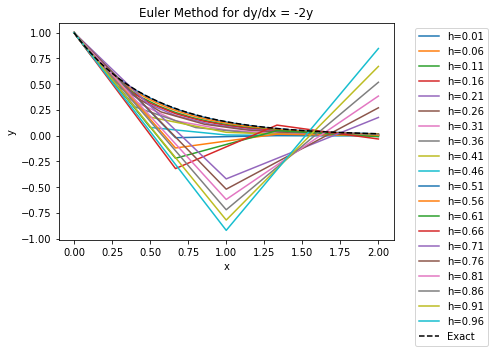